<a href="https://colab.research.google.com/github/balajiduddukuri/Langchain_practice/blob/Ultimate-Content-Repurposer/LangChain_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Agent SDLC Workflow with LangGraph and Google Gemini
This notebook demonstrates a collaborative Software Development Life Cycle (SDLC) workflow using multiple AI personas (BA, PM, Developer, Tester, DevOps) powered by Google Gemini and orchestrated via LangGraph.

## 1. Environment Setup
Install necessary libraries including `langchain`, `langgraph`, and `langchain-experimental` for the Python REPL tool.

## 2. Model and Tool Configuration
We configure the Google Gemini model and define a `python_repl` tool that allows the Developer persona to execute code snippets for logic validation.

## 3. Workflow State and Persona Definition
We define the `SDLCState` to track conversation history and the current persona. Each persona is assigned a specific system prompt and transition instruction.

## 4. Graph Construction and Routing
The workflow is built as a `StateGraph`. We use a unified routing logic that handles tool calls (returning to the Developer) and persona transitions (moving forward in the SDLC sequence) with loop protection.

## 5. Workflow Execution
Finally, we trigger the workflow with a specific user task. The graph streams the output of each persona until it reaches a `FINAL:` state or a turn limit.

In [65]:
!pip install -q langchain langchain-google-genai langgraph ipython google-generativeai langchain-experimental

In [66]:
import os
from typing import TypedDict, Annotated, Literal, List

from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import Runnable
from langchain_google_genai import ChatGoogleGenerativeAI

from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.types import Command

from langchain_core.tools import tool
from langchain_experimental.tools.python.tool import PythonREPLTool
from langgraph.prebuilt import ToolNode, tools_condition

In [67]:
# Low-level REPL backend
_repl = PythonREPLTool()

@tool
def python_repl(
    code: str,
):
    """Execute Python code. Use print(...) to show values."""
    try:
        result = _repl.invoke(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return (
        "Successfully executed:\n```python\n"
        + code
        + "\n```\nStdout:\n"
        + str(result)
        + "\n\nIf you have completed all tasks, respond with FINAL:"
    )

dev_tools = [python_repl]

In [68]:
import os
from google.colab import userdata

# LangChain core + Google Gemini Chat wrapper
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from langchain_core.prompts import PromptTemplate

# Load and assert API key (store it in Colab with key name: "google_api_key")
os.environ["GOOGLE_API_KEY"] = userdata.get("GEMINI_API_KEY")
assert os.environ.get("GOOGLE_API_KEY"), (
    "Missing GOOGLE_API_KEY. In Colab, run: "
    "from google.colab import userdata; userdata.set('google_api_key', 'YOUR_KEY')"
)
print("Google API key is loaded successfully.")

Google API key is loaded successfully.


In [69]:
# ===============================
# 3) Helper: build Gemini LLM
# ===============================
# Base LLM
llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",  temperature=0.4,
)
llm

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-3-flash-preview', temperature=0.4, client=<google.genai.client.Client object at 0x7ea7a4822000>, default_metadata=(), model_kwargs={})

In [70]:
class SDLCState(TypedDict):
    messages: Annotated[List[BaseMessage], "add_messages"]
    current_persona: str
    final_output: str

def append_ai(state: SDLCState, content: str, name: str) -> SDLCState:
    msgs = state.get("messages", [])
    msgs = msgs + [AIMessage(content=content, name=name)]
    state["messages"] = msgs
    return state

In [71]:
BA_SYSTEM = """
Persona: Business Analyst.
Action: Provide epics and user stories.
End with: NEXT: Product Manager
"""

PM_SYSTEM = """
Persona: Product Manager.
Action: Define steps.
End with: NEXT: Developer
"""

DEV_SYSTEM = """
Persona: Developer.
Action: Provide code/design. Use `python_repl` for logic checks.
End with: NEXT: Tester
"""

QA_SYSTEM = """
Persona: Tester.
Action: List 2 test cases.
End with: NEXT: DevOps
"""

DEVOPS_SYSTEM = """
Persona: DevOps.
Action: publish Deployment plan.
End with: FINAL:
"""

In [72]:
def make_persona_node(system_prompt: str, persona_name: str):
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_prompt),
            ("placeholder", "{history}"),
            ("human", "{task}"),
        ]
    )

    # Use the model directly or ensure the chain is invoked correctly
    # Adding .invoke() inside the node handles the ChatPromptValue conversion

    def node(state: SDLCState) -> SDLCState:
        history = state.get("messages", [])
        last_human = None
        for m in reversed(history):
            if isinstance(m, HumanMessage):
                last_human = m
                break
        task_text = last_human.content if last_human else "Continue the SDLC workflow."

        # Generate formatted messages from prompt
        formatted_prompt = prompt.invoke({"history": history, "task": task_text})

        # Pass the underlying message list to the LLM
        ai_msg = llm.invoke(formatted_prompt.to_messages())

        state["messages"] = history + [ai_msg]
        state["current_persona"] = persona_name
        return state

    return node

In [73]:
from langchain_core.runnables import Runnable

def make_persona_node_with_tools(system_prompt: str, persona_name: str, tools=None):
    base_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_prompt),
            ("placeholder", "{history}"),
            ("human", "{task}"),
        ]
    )
    model = llm
    if tools:
        model = llm.bind_tools(tools)

    def node(state: SDLCState) -> SDLCState:
        print(f"\n>>> Entering Node: {persona_name}")
        history = state.get("messages", [])
        last_human = None
        for m in reversed(history):
            if isinstance(m, HumanMessage):
                last_human = m
                break
        task_text = last_human.content if last_human else "Continue the SDLC workflow."
        print(f">>> Task for {persona_name}: {task_text[:100]}...")

        formatted_prompt = base_prompt.invoke({"history": history, "task": task_text})
        ai_msg = model.invoke(formatted_prompt.to_messages())

        state["messages"] = history + [ai_msg]
        state["current_persona"] = persona_name
        print(f">>> {persona_name} response generated.")
        return state

    return node

# Re-initialize nodes with tool support where needed
ba_node = make_persona_node(BA_SYSTEM, "BA")
pm_node = make_persona_node(PM_SYSTEM, "PM")
dev_node_with_tools = make_persona_node_with_tools(DEV_SYSTEM, "DEV", tools=dev_tools)
qa_node = make_persona_node(QA_SYSTEM, "QA")
devops_node = make_persona_node(DEVOPS_SYSTEM, "DEVOPS")

In [74]:
tool_node = ToolNode(dev_tools)


In [76]:
# This cell is redundant as the workflow is compiled in cell d5Z39hZ_T-Wz
print("Redundant graph definition skipped. Using unified routing in d5Z39hZ_T-Wz.")

Redundant graph definition skipped. Using unified routing in d5Z39hZ_T-Wz.


In [78]:
# Nodes are correctly initialized in cell 4C7317lfckmL
print("Nodes initialized in 4C7317lfckmL.")

Nodes initialized in 4C7317lfckmL.


In [77]:
# Redundant routing logic. The robust version with loop protection is in cell 7ba0cc9e
print("Using robust routing from cell 7ba0cc9e.")

Using robust routing from cell 7ba0cc9e.


In [80]:
workflow = StateGraph(SDLCState)

workflow.add_node("BA", ba_node)
workflow.add_node("PM", pm_node)
workflow.add_node("DEV", dev_node_with_tools)
workflow.add_node("QA", qa_node)
workflow.add_node("DEVOPS", devops_node)
workflow.add_node("tools", ToolNode(dev_tools))

workflow.add_edge(START, "BA")

def routing_logic(state: SDLCState):
    """Combined logic to handle tool calls or persona transitions."""
    msgs = state.get("messages", [])
    if msgs and hasattr(msgs[-1], "tool_calls") and msgs[-1].tool_calls:
        return "tools"
    # Fallback to the standard route_next logic
    return route_next(state)

# Attach routing to every persona node
for node_name in ["BA", "PM", "DEV", "QA", "DEVOPS"]:
    workflow.add_conditional_edges(
        node_name,
        routing_logic,
        {
            "tools": "tools",
            "BA": "BA",
            "PM": "PM",
            "DEV": "DEV",
            "QA": "QA",
            "DEVOPS": "DEVOPS",
            "__end__": END
        }
    )

workflow.add_edge("tools", "DEV")

graph = workflow.compile()
print("Workflow compiled successfully with unified routing.")

Workflow compiled successfully with unified routing.


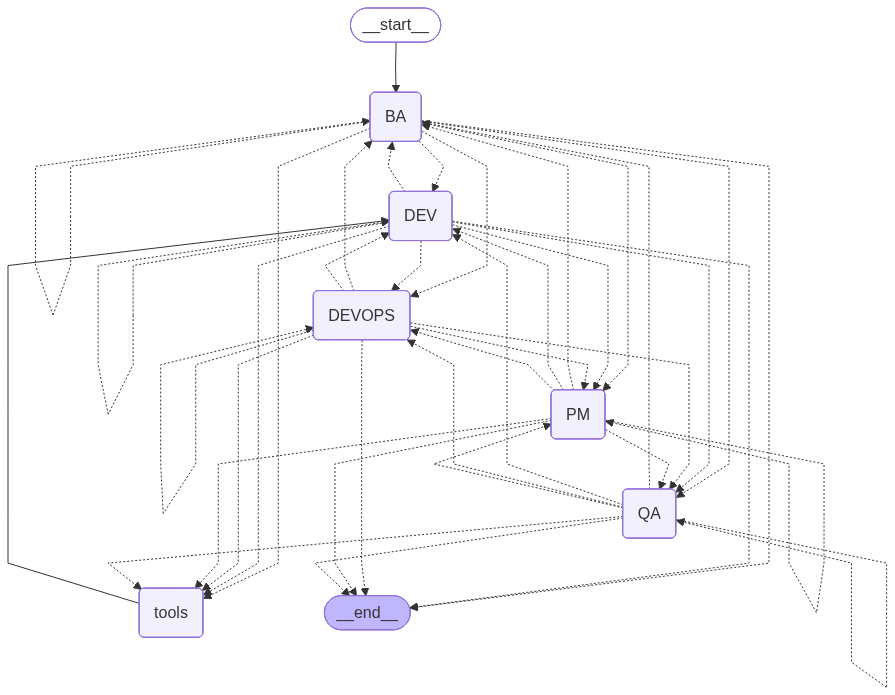

In [81]:
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization skipped:", e)

In [82]:
def route_next(state: SDLCState) -> Literal["BA", "PM", "DEV", "QA", "DEVOPS", "__end__"]:
    msgs = state.get("messages", [])
    if not msgs:
        return "BA"

    # Count occurrences of the current persona to prevent looping
    current_persona = state.get("current_persona", "BA")
    persona_count = sum(1 for m in msgs if getattr(m, 'name', '') == current_persona or (isinstance(m, AIMessage) and current_persona in str(m.content)))

    if persona_count >= 2:
        # Force move to next in sequence if looping detected
        order = ["BA", "PM", "DEV", "QA", "DEVOPS"]
        try:
            idx = order.index(current_persona)
            return order[idx + 1] if idx + 1 < len(order) else "__end__"
        except:
            return "__end__"

    last = msgs[-1]
    content = getattr(last, 'content', str(last))
    if isinstance(content, list):
        content = " ".join([p.get('text', '') if isinstance(p, dict) else str(p) for p in content])

    content_upper = str(content).upper()

    if "FINAL:" in content_upper:
        state["final_output"] = str(content)
        return "__end__"

    if "NEXT:" in content_upper:
        if "PRODUCT MANAGER" in content_upper: return "PM"
        if "DEVELOPER" in content_upper: return "DEV"
        if "TESTER" in content_upper: return "QA"
        if "DEVOPS" in content_upper: return "DEVOPS"
        if "BUSINESS ANALYST" in content_upper: return "BA"

    order = ["BA", "PM", "DEV", "QA", "DEVOPS"]
    try:
        idx = order.index(current_persona)
        return order[idx + 1] if idx + 1 < len(order) else "__end__"
    except:
        return "__end__"

print("Route logic updated with loop protection (max 2 turns per persona).")

Route logic updated with loop protection (max 2 turns per persona).


In [83]:
'''
user_task = """
Design and deliver a new Salesforce Marketing Cloud journey
for Japan customers that handles onboarding, preference capture,
and multi‑channel notifications, aligned with JO@S guidelines.
"""
'''

'\nuser_task = """\nDesign and deliver a new Salesforce Marketing Cloud journey\nfor Japan customers that handles onboarding, preference capture,\nand multi‑channel notifications, aligned with JO@S guidelines.\n"""\n'

In [ ]:
import time
user_task = "word count on 'ELEPHANT is drinking water' "
initial_state = {
    "messages": [HumanMessage(content=user_task)],
    "current_persona": "BA",
    "final_output": "",
}

max_retries = 3
retry_delay = 5

for attempt in range(max_retries):
    try:
        print(f"Starting SDLC Workflow (Attempt {attempt+1})...\n")
        final_state = initial_state
        for step in graph.stream(initial_state):
            for node_name, state_update in step.items():
                print(f"\n=== Node: {node_name} (Persona: {state_update.get('current_persona', 'N/A')}) ===")
                if "messages" in state_update and state_update["messages"]:
                    msg_content = state_update["messages"][-1].content
                    print(str(msg_content)[:1000] + "...")
                final_state = state_update

        from IPython.display import Markdown, display
        display(Markdown("## Workflow Complete"))
        display(Markdown(final_state.get("final_output", "No final output generated.")))
        break
    except Exception as e:
        if "503" in str(e) and attempt < max_retries - 1:
            print(f"Server busy (503). Retrying in {retry_delay}s...")
            time.sleep(retry_delay)
        else:
            print(f"Execution error: {e}")
            break

Starting SDLC Workflow (Attempt 1)...

